In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv')

print('Data shape:', df.shape)
print('Default rate:', df['default.payment.next.month'].mean().round(3))
print('Setup complete!')

Data shape: (30000, 25)
Default rate: 0.221
Setup complete!


**Step 1 Exploratory Data Analysis (EDA)**

Exploring customer demographics and payment behavior to understand what drives credit card default.

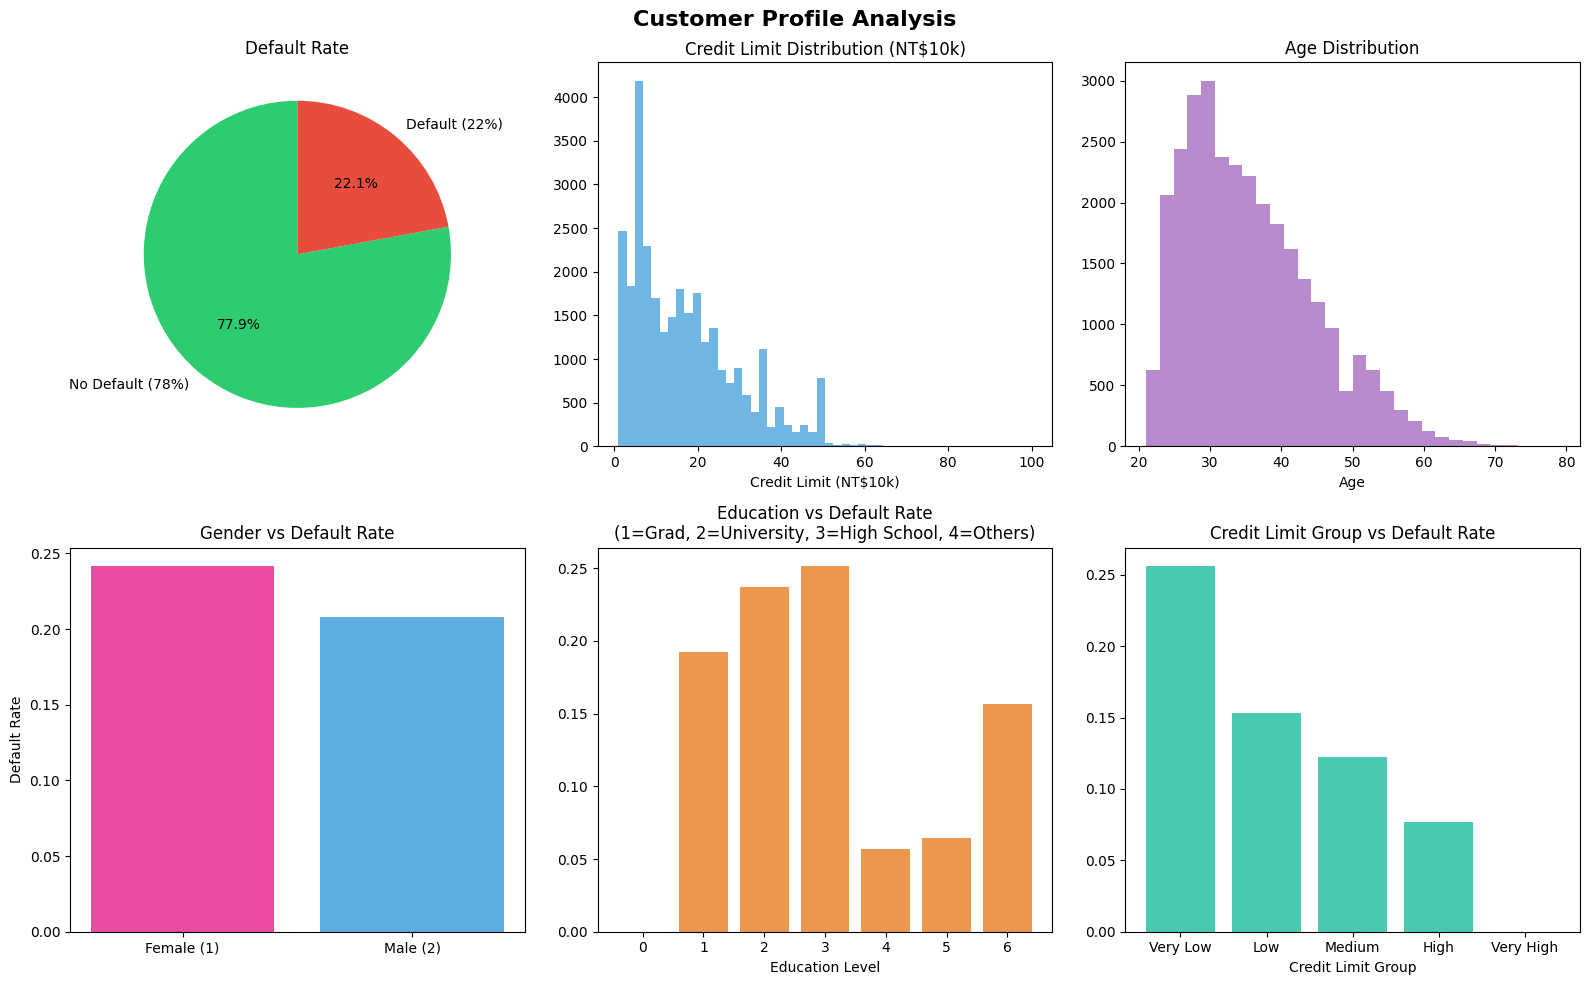

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Profile Analysis', fontsize=16, fontweight='bold')

# 1. Default rate
axes[0,0].pie(df['default.payment.next.month'].value_counts(),
              labels=['No Default (78%)', 'Default (22%)'],
              colors=['#2ecc71', '#e74c3c'],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Default Rate')

# 2. Credit limit distribution
axes[0,1].hist(df['LIMIT_BAL']/10000, bins=50, color='#3498db', alpha=0.7)
axes[0,1].set_title('Credit Limit Distribution (NT$10k)')
axes[0,1].set_xlabel('Credit Limit (NT$10k)')

# 3. Age distribution
axes[0,2].hist(df['AGE'], bins=30, color='#9b59b6', alpha=0.7)
axes[0,2].set_title('Age Distribution')
axes[0,2].set_xlabel('Age')

# 4. Gender vs default rate
sex_default = df.groupby('SEX')['default.payment.next.month'].mean()
axes[1,0].bar(['Female (1)', 'Male (2)'], sex_default.values, color=['#e91e8c', '#3498db'], alpha=0.8)
axes[1,0].set_title('Gender vs Default Rate')
axes[1,0].set_ylabel('Default Rate')

# 5. Education vs default rate
edu_default = df.groupby('EDUCATION')['default.payment.next.month'].mean()
axes[1,1].bar(edu_default.index.astype(str), edu_default.values, color='#e67e22', alpha=0.8)
axes[1,1].set_title('Education vs Default Rate\n(1=Grad, 2=University, 3=High School, 4=Others)')
axes[1,1].set_xlabel('Education Level')

# 6. Credit limit group vs default rate
df['LIMIT_BAL_GROUP'] = pd.cut(df['LIMIT_BAL'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
limit_default = df.groupby('LIMIT_BAL_GROUP', observed=True)['default.payment.next.month'].mean()
axes[1,2].bar(limit_default.index, limit_default.values, color='#1abc9c', alpha=0.8)
axes[1,2].set_title('Credit Limit Group vs Default Rate')
axes[1,2].set_xlabel('Credit Limit Group')

plt.tight_layout()
plt.show()

Key observation: Gender and education level show minimal difference in default rates, suggesting these features may have limited predictive power.

**Step 2 Data Cleaning & Feature Engineering**

In [4]:
# Check unique values of categorical variables
print('SEX unique values:', sorted(df['SEX'].unique()))
print('EDUCATION unique values:', sorted(df['EDUCATION'].unique()))
print('MARRIAGE unique values:', sorted(df['MARRIAGE'].unique()))
print()

# Count per category
print('EDUCATION value counts:')
print(df['EDUCATION'].value_counts().sort_index())
print()
print('MARRIAGE value counts:')
print(df['MARRIAGE'].value_counts().sort_index())

SEX unique values: [np.int64(1), np.int64(2)]
EDUCATION unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


Data cleaning: EDUCATION contained undefined values (0, 4, 5, 6) and MARRIAGE contained value 0, neither of which are documented in the dataset description. These were consolidated into an "Other" category to prevent the model from treating them as meaningful numeric values.

In [5]:
# Copy original data to preserve raw values
df_clean = df.copy()

# EDUCATION: consolidate undefined values (0, 5, 6) into 'Other' category (4)
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: consolidate undefined value (0) into 'Other' category (3)
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})

# Verify results
print('EDUCATION after cleaning:', sorted(df_clean['EDUCATION'].unique()))
print('MARRIAGE after cleaning:', sorted(df_clean['MARRIAGE'].unique()))
print()
print('EDUCATION value counts:')
print(df_clean['EDUCATION'].value_counts().sort_index())
print('MARRIAGE value counts:')
print(df_clean['MARRIAGE'].value_counts().sort_index())

EDUCATION after cleaning: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE after cleaning: [np.int64(1), np.int64(2), np.int64(3)]

EDUCATION value counts:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64
MARRIAGE value counts:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


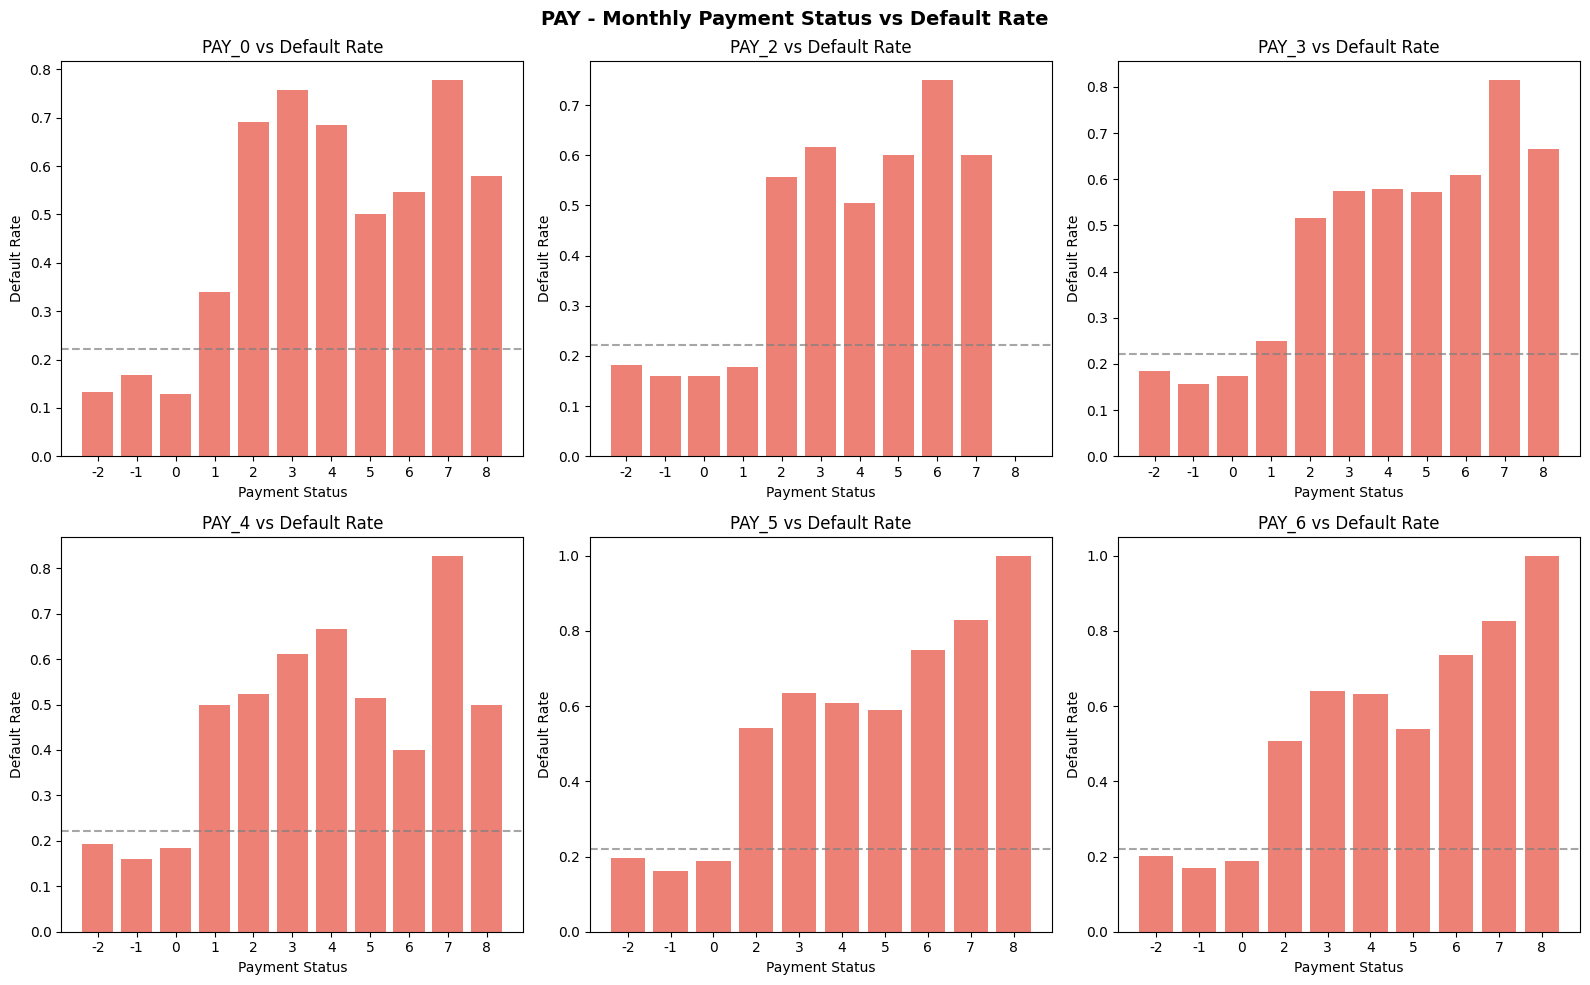

Correlation with default:
PAY_0: 0.325
PAY_2: 0.264
PAY_3: 0.235
PAY_4: 0.217
PAY_5: 0.204
PAY_6: 0.187


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PAY - Monthly Payment Status vs Default Rate', fontsize=14, fontweight='bold')

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for i, col in enumerate(pay_cols):
    ax = axes[i//3][i%3]
    pay_default = df_clean.groupby(col)['default.payment.next.month'].mean()
    ax.bar(pay_default.index.astype(str), pay_default.values, color='#e74c3c', alpha=0.7)
    ax.set_title(f'{col} vs Default Rate')
    ax.set_xlabel('Payment Status')
    ax.set_ylabel('Default Rate')
    ax.axhline(y=0.221, color='gray', linestyle='--', alpha=0.7, label='Average')

plt.tight_layout()
plt.show()

# Correlation between each PAY column and default
print('Correlation with default:')
for col in pay_cols:
    corr = df_clean[col].corr(df_clean['default.payment.next.month'])
    print(f'{col}: {corr:.3f}')

Feature engineering: Three new features were created to better capture default risk beyond the raw payment columns.


* AVG_PAY_DELAY: Average repayment delay across the past 6 months, representing the customer's overall payment behavior pattern
* PAY_RATIO_1: Most recent payment amount divided by bill amount, representing how much of the bill the customer actually paid
* BILL_UTIL: Most recent bill amount divided by credit limit, representing how much of the credit limit is being utilized


In [7]:
# Feature 1: Average repayment delay over the past 6 months
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_clean['AVG_PAY_DELAY'] = df_clean[pay_cols].mean(axis=1)

# Feature 2: Most recent payment ratio (add 1 to avoid division by zero)
df_clean['PAY_RATIO_1'] = df_clean['PAY_AMT1'] / (df_clean['BILL_AMT1'] + 1)

# Feature 3: Credit utilization ratio (most recent bill / credit limit)
df_clean['BILL_UTIL'] = df_clean['BILL_AMT1'] / (df_clean['LIMIT_BAL'] + 1)

# Correlation between new features and default
new_features = ['AVG_PAY_DELAY', 'PAY_RATIO_1', 'BILL_UTIL']
print('Correlation of new features with default:')
for col in new_features:
    corr = df_clean[col].corr(df_clean['default.payment.next.month'])
    print(f'{col}: {corr:.3f}')

Correlation of new features with default:
AVG_PAY_DELAY: 0.282
PAY_RATIO_1: nan
BILL_UTIL: 0.086


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


Note: PAY_RATIO_1 initially returned NaN due to negative values in BILL_AMT columns (caused by overpayments or refunds). These were clipped to 0 before recalculating.

In [8]:
print('BILL_AMT1 basic statistics:')
print(df_clean['BILL_AMT1'].describe())
print()
print('Negative value count:', (df_clean['BILL_AMT1'] < 0).sum())
print('PAY_AMT1 basic statistics:')
print(df_clean['PAY_AMT1'].describe())
print()
print('Negative value count:', (df_clean['PAY_AMT1'] < 0).sum())

BILL_AMT1 basic statistics:
count     30000.000000
mean      51223.330900
std       73635.860576
min     -165580.000000
25%        3558.750000
50%       22381.500000
75%       67091.000000
max      964511.000000
Name: BILL_AMT1, dtype: float64

Negative value count: 590
PAY_AMT1 basic statistics:
count     30000.000000
mean       5663.580500
std       16563.280354
min           0.000000
25%        1000.000000
50%        2100.000000
75%        5006.000000
max      873552.000000
Name: PAY_AMT1, dtype: float64

Negative value count: 0


In [9]:
# Clip negative bill amounts to 0 (caused by overpayments or refunds)
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

for col in bill_cols:
    df_clean[col] = df_clean[col].clip(lower=0)

# Recalculate features with cleaned data
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_clean['AVG_PAY_DELAY'] = df_clean[pay_cols].mean(axis=1)
df_clean['PAY_RATIO_1'] = df_clean['PAY_AMT1'] / (df_clean['BILL_AMT1'] + 1)
df_clean['BILL_UTIL'] = df_clean['BILL_AMT1'] / (df_clean['LIMIT_BAL'] + 1)

# Verify NaN is resolved
print('Correlation of new features with default:')
new_features = ['AVG_PAY_DELAY', 'PAY_RATIO_1', 'BILL_UTIL']
for col in new_features:
    corr = df_clean[col].corr(df_clean['default.payment.next.month'])
    print(f'{col}: {corr:.3f}')

print()
print('NaN check:')
print(df_clean[new_features].isnull().sum())

Correlation of new features with default:
AVG_PAY_DELAY: 0.282
PAY_RATIO_1: -0.015
BILL_UTIL: 0.086

NaN check:
AVG_PAY_DELAY    0
PAY_RATIO_1      0
BILL_UTIL        0
dtype: int64


**Step 3 Modeling**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Define features and target variable
feature_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
                'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                'AVG_PAY_DELAY', 'PAY_RATIO_1', 'BILL_UTIL']

X = df_clean[feature_cols]
y = df_clean['default.payment.next.month']

# Train/test split: 80% training, 20% testing
# stratify=y ensures both sets maintain the same default rate ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)
print()
print('Training set default rate:', y_train.mean().round(3))
print('Test set default rate:', y_test.mean().round(3))

Training set size: (24000, 20)
Test set size: (6000, 20)

Training set default rate: 0.221
Test set default rate: 0.221


In [11]:
# Standardize features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Print results
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC:', roc_auc_score(y_test, y_prob_lr).round(3))

print()
print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))
print('AUC-ROC:', roc_auc_score(y_test, y_prob_rf).round(3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.71      0.78      4673
           1       0.37      0.61      0.46      1327

    accuracy                           0.69      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.69      0.71      6000

AUC-ROC: 0.71

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

AUC-ROC: 0.756


Two models were trained: Logistic Regression and Random Forest, both with class_weight='balanced' to account for the imbalanced dataset (78% non-default vs 22% default).

In a credit default context, recall matters more than precision — missing a customer who will default is more costly than flagging a customer who won't. Although Logistic Regression achieves higher recall at the default threshold, Random Forest demonstrates stronger overall discrimination ability (AUC-ROC: 0.756 vs 0.710), making it the preferred base model. We will next explore whether recall can be further improved through threshold tuning and hyperparameter optimization.

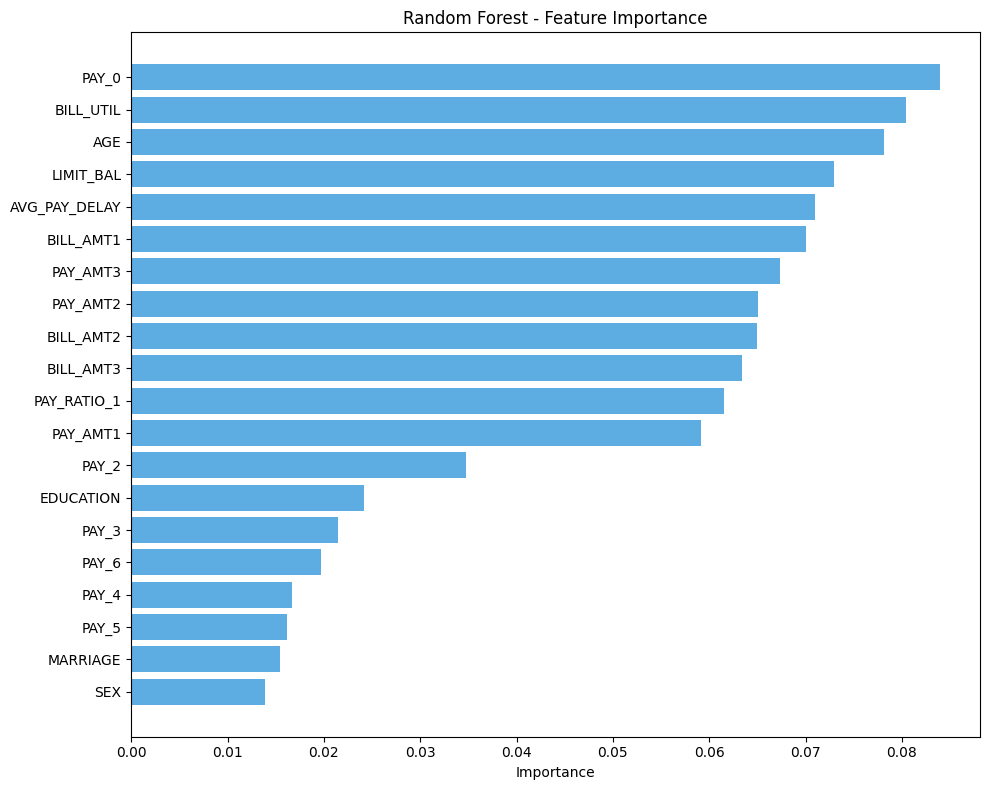

      feature  importance
        PAY_0    0.083910
    BILL_UTIL    0.080380
          AGE    0.078188
    LIMIT_BAL    0.072944
AVG_PAY_DELAY    0.070989
    BILL_AMT1    0.070087
     PAY_AMT3    0.067332
     PAY_AMT2    0.065029
    BILL_AMT2    0.064911
    BILL_AMT3    0.063379
  PAY_RATIO_1    0.061579
     PAY_AMT1    0.059163
        PAY_2    0.034790
    EDUCATION    0.024137
        PAY_3    0.021507
        PAY_6    0.019664
        PAY_4    0.016650
        PAY_5    0.016119
     MARRIAGE    0.015405
          SEX    0.013836


In [12]:
# feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'], 
         color='#3498db', alpha=0.8)
plt.xlabel('Importance')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

In [13]:
# Tune prediction threshold to improve recall
thresholds = [0.3, 0.4, 0.5]

print('=== Random Forest — Threshold Tuning ===')
for thres in thresholds:
    y_pred_thres = (y_prob_rf >= thres).astype(int)
    report = classification_report(y_test, y_pred_thres, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    print(f'Threshold={thres} → Default Recall: {recall:.2f} | Precision: {precision:.2f} | F1: {f1:.2f}')

=== Random Forest — Threshold Tuning ===
Threshold=0.3 → Default Recall: 0.54 | Precision: 0.50 | F1: 0.52
Threshold=0.4 → Default Recall: 0.45 | Precision: 0.58 | F1: 0.50
Threshold=0.5 → Default Recall: 0.36 | Precision: 0.62 | F1: 0.45


Applying GridSearchCV to search for the optimal hyperparameter 
combination, with recall as the optimization target.

In [14]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV: test all parameter combinations, optimizing for recall
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best parameters:')
print(grid_search.best_params_)
print()
print('Best Recall (cross validation):', grid_search.best_score_.round(3))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}

Best Recall (cross validation): 0.573


In [15]:
# Get predictions from optimized model
best_rf = grid_search.best_estimator_
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print('=== Optimized Random Forest — Threshold Tuning ===')
thresholds = [0.3, 0.4, 0.5]
for thres in thresholds:
    y_pred_thres = (y_prob_best >= thres).astype(int)
    report = classification_report(y_test, y_pred_thres, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    print(f'Threshold={thres} → Recall: {recall:.2f} | Precision: {precision:.2f} | F1: {f1:.2f}')

=== Optimized Random Forest — Threshold Tuning ===
Threshold=0.3 → Recall: 0.87 | Precision: 0.31 | F1: 0.46
Threshold=0.4 → Recall: 0.70 | Precision: 0.40 | F1: 0.51
Threshold=0.5 → Recall: 0.58 | Precision: 0.51 | F1: 0.54


**Step 4 Results & Business Recommendations**

In [16]:
# Overall model comparison
results = {
    'Model': [
        'Logistic Regression',
        'Random Forest (threshold=0.3)',
        'Random Forest (threshold=0.4)',
        'Random Forest (threshold=0.5)',
        'Optimized RF (threshold=0.3)',
        'Optimized RF (threshold=0.4)',
        'Optimized RF (threshold=0.5)'
    ],
    'Recall': [],
    'Precision': [],
    'F1': [],
    'AUC-ROC': []
}

# Compare different models
models = [
    (y_prob_lr, 0.5),
    (y_prob_rf, 0.3),
    (y_prob_rf, 0.4),
    (y_prob_rf, 0.5),
    (y_prob_best, 0.3),
    (y_prob_best, 0.4),
    (y_prob_best, 0.5)
]

for prob, thres in models:
    pred = (prob >= thres).astype(int)
    report = classification_report(y_test, pred, output_dict=True)
    results['Recall'].append(round(report['1']['recall'], 3))
    results['Precision'].append(round(report['1']['precision'], 3))
    results['F1'].append(round(report['1']['f1-score'], 3))
    results['AUC-ROC'].append(round(roc_auc_score(y_test, prob), 3))

comparison_df = pd.DataFrame(results)
print('=== Full Model Comparison ===')
print(comparison_df.to_string(index=False))

=== Full Model Comparison ===
                        Model  Recall  Precision    F1  AUC-ROC
          Logistic Regression   0.605      0.374 0.462    0.710
Random Forest (threshold=0.3)   0.544      0.503 0.523    0.756
Random Forest (threshold=0.4)   0.445      0.575 0.502    0.756
Random Forest (threshold=0.5)   0.356      0.624 0.453    0.756
 Optimized RF (threshold=0.3)   0.867      0.309 0.456    0.778
 Optimized RF (threshold=0.4)   0.697      0.401 0.509    0.778
 Optimized RF (threshold=0.5)   0.580      0.509 0.542    0.778


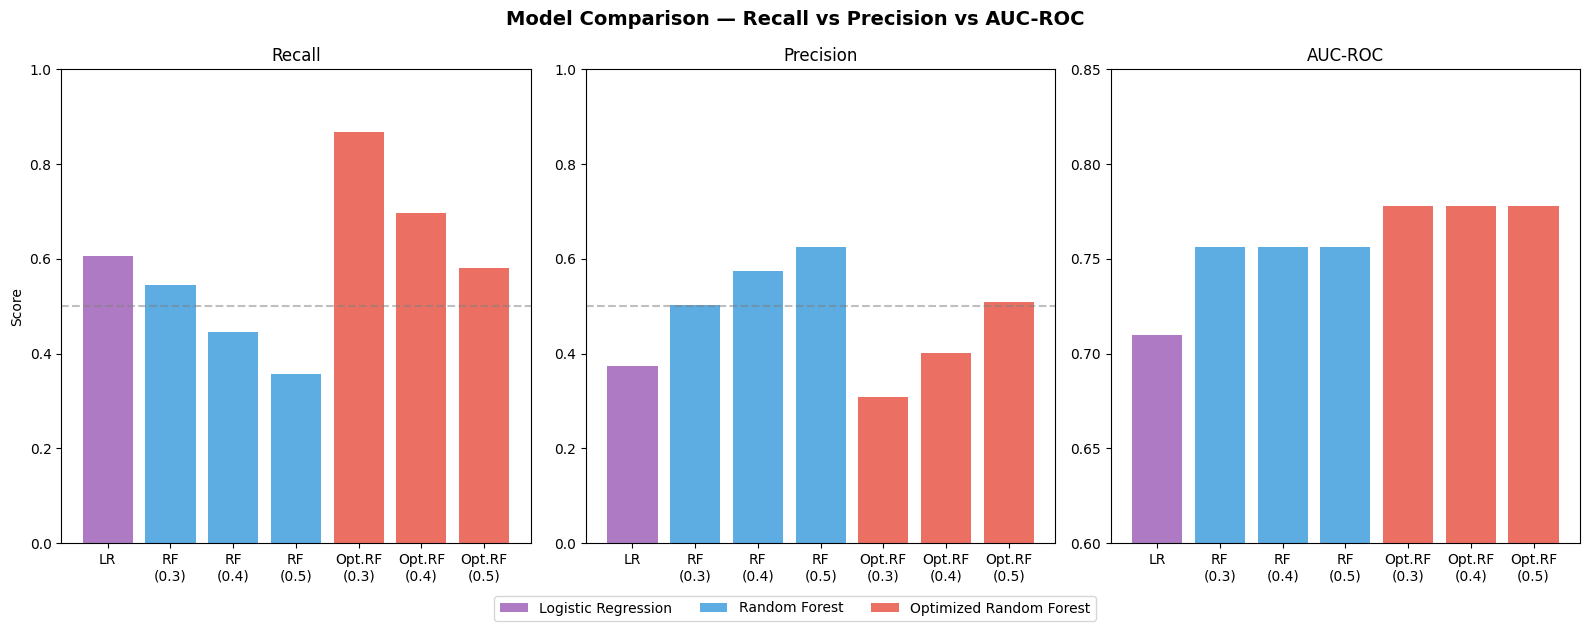

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Comparison — Recall vs Precision vs AUC-ROC', 
             fontsize=14, fontweight='bold')

models_short = [
    'LR', 'RF\n(0.3)', 'RF\n(0.4)', 'RF\n(0.5)',
    'Opt.RF\n(0.3)', 'Opt.RF\n(0.4)', 'Opt.RF\n(0.5)'
]

colors = ['#9b59b6', '#3498db', '#3498db', '#3498db',
          '#e74c3c', '#e74c3c', '#e74c3c']

# Recall
axes[0].bar(models_short, comparison_df['Recall'], color=colors, alpha=0.8)
axes[0].set_title('Recall')
axes[0].set_ylabel('Score')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylim(0, 1)

# Precision
axes[1].bar(models_short, comparison_df['Precision'], color=colors, alpha=0.8)
axes[1].set_title('Precision')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 1)

# AUC-ROC
axes[2].bar(models_short, comparison_df['AUC-ROC'], color=colors, alpha=0.8)
axes[2].set_title('AUC-ROC')
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_ylim(0.6, 0.85)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9b59b6', alpha=0.8, label='Logistic Regression'),
    Patch(facecolor='#3498db', alpha=0.8, label='Random Forest'),
    Patch(facecolor='#e74c3c', alpha=0.8, label='Optimized Random Forest')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

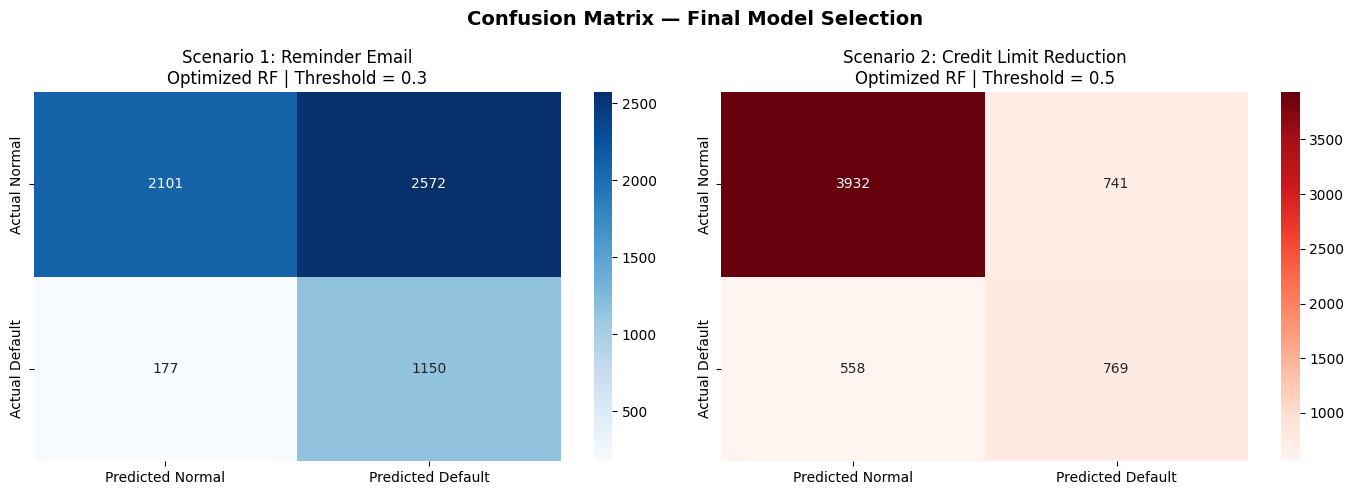

=== Business Impact ===
Scenario 1 (Threshold=0.3):
  Defaults captured: 1150/1327 (86.7%)
  Normal customers flagged: 2572

Scenario 2 (Threshold=0.5):
  Defaults captured: 769/1327 (58.0%)
  Normal customers flagged: 741


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Final Model Selection', 
             fontsize=14, fontweight='bold')

# Scenario 1: Low-cost action (reminder email) — Optimized RF, threshold=0.3
y_pred_s1 = (y_prob_best >= 0.3).astype(int)
cm_s1 = confusion_matrix(y_test, y_pred_s1)
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Normal', 'Predicted Default'],
            yticklabels=['Actual Normal', 'Actual Default'])
axes[0].set_title('Scenario 1: Reminder Email\nOptimized RF | Threshold = 0.3')

# Scenario 2: High-impact action (credit limit reduction) — Optimized RF, threshold=0.5
y_pred_s2 = (y_prob_best >= 0.5).astype(int)
cm_s2 = confusion_matrix(y_test, y_pred_s2)
sns.heatmap(cm_s2, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Predicted Normal', 'Predicted Default'],
            yticklabels=['Actual Normal', 'Actual Default'])
axes[1].set_title('Scenario 2: Credit Limit Reduction\nOptimized RF | Threshold = 0.5')

plt.tight_layout()
plt.show()

# Print business impact
print('=== Business Impact ===')
tn, fp, fn, tp = cm_s1.ravel()
print(f'Scenario 1 (Threshold=0.3):')
print(f'  Defaults captured: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Normal customers flagged: {fp}')
print()
tn, fp, fn, tp = cm_s2.ravel()
print(f'Scenario 2 (Threshold=0.5):')
print(f'  Defaults captured: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'  Normal customers flagged: {fp}')

## Credit Card Default Prediction — Executive Summary

**Objective**
Using 30,000 customer records with demographic information and 
6 months of payment history, this model identifies high-risk 
customers before they default, enabling the bank to intervene early.

**Key Findings**
The three most important predictors of default are:
1. PAY_0 — most recent repayment status (strongest signal)
2. BILL_UTIL — credit utilization ratio
3. AGE — customer age

Notably, gender and marital status contribute very little to 
predictive power, suggesting these factors should not be used 
as primary risk indicators.

**Model Development**
Three models were evaluated: Logistic Regression, Random Forest, 
and an optimized Random Forest via GridSearchCV. While Logistic 
Regression achieved reasonable recall, Random Forest demonstrated 
stronger overall discrimination (AUC-ROC: 0.756 vs 0.710). 
After hyperparameter tuning optimizing for recall, the Optimized 
Random Forest achieved the best overall performance 
(AUC-ROC: 0.778).

**Final Model Selection**
The optimal threshold depends on the intervention type and its 
impact on customers:

Scenario 1 — Low-cost action (e.g. reminder email):
Optimized RF | Threshold = 0.3
- Captures 86.7% of customers who will default (1,150 / 1,327)
- 2,572 normal customers flagged — acceptable given low cost 
  and non-intrusive nature of the action

Scenario 2 — High-impact action (e.g. credit limit reduction):
Optimized RF | Threshold = 0.5
- Captures 58.0% of customers who will default (769 / 1,327)
- Only 741 normal customers flagged — reduces risk of 
  penalizing good customers unnecessarily

**Business Recommendations**
A two-tier early warning system is recommended:

Tier 1 — Proactive outreach (Threshold = 0.3):
When the model flags a customer as high-risk, trigger an 
automated reminder email or SMS notification.

Tier 2 — Credit limit reduction (Threshold = 0.5):
If a customer shows repayment delays for two consecutive months, 
initiate a credit limit reduction review.

Compared to the current reactive approach of waiting for default 
to occur, this system moves risk intervention 1–2 months earlier. 
The choice of threshold should ultimately align with the bank's 
risk appetite and the cost of each intervention action.

Note: Logistic Regression hyperparameter tuning (e.g. 
regularization parameter C) was not explored in this analysis 
and could be a direction for future improvement.